# Feature Engineering — Techniques, Transformations, Outlier Detection, Target Encoding

*Part of the ML Course Reference Series.*

## FE1: What is feature engineering and why does it matter?

Feature engineering = creating or transforming input features to make patterns easier for the model to learn.

**Types of transformations:**
| Technique | When to use | Example |
|---|---|---|
| **Log transform** | Right-skewed distributions | Price, income, population |
| **Polynomial features** | Nonlinear relationships | x² or x₁·x₂ interaction |
| **Binning** | Continuous → categorical | Age groups: 0-18, 18-35, ... |
| **Ratio features** | Domain-derived ratios | income/expense, area/rooms |
| **Date/time extraction** | Timestamp features | hour_of_day, day_of_week |
| **Interaction terms** | Combined effect of two features | bmi × age |

**Rule:** a well-engineered feature often beats a more complex model on raw features.

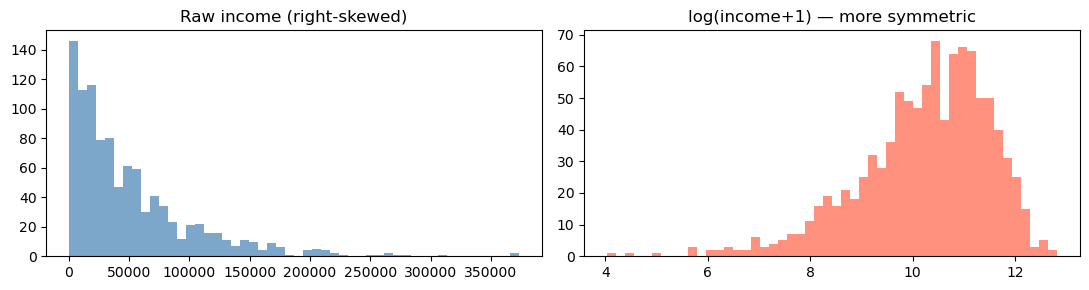

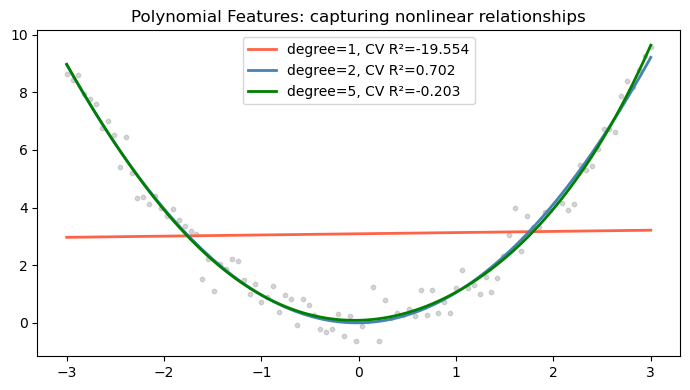

Original features: ['age', 'bmi']
Engineered features: ['age_x_bmi', 'bmi_sq', 'log_bmi']
    age        bmi    age_x_bmi      bmi_sq   log_bmi
0  28.0  22.569029   631.932822  509.361086  3.116579
1  41.0  27.101134  1111.146475  734.471440  3.299576
2  30.0  24.488016   734.640494  599.662950  3.198184
3  22.0  21.747182   478.438002  472.939921  3.079484
4  38.0  21.628938   821.899632  467.810946  3.074032


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

rng = np.random.default_rng(42)

# ── 1. Log transform for skewed data ────────────────────────────────────────
income = rng.exponential(scale=50000, size=1000)
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].hist(income, bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('Raw income (right-skewed)')
axes[1].hist(np.log1p(income), bins=50, color='tomato', alpha=0.7)
axes[1].set_title('log(income+1) — more symmetric')
plt.tight_layout()
plt.show()

# ── 2. Polynomial features capture nonlinear patterns ────────────────────────
x_raw = np.linspace(-3, 3, 100).reshape(-1, 1)
y_true = x_raw.ravel()**2 + rng.normal(0, 0.5, 100)

results = {}
for degree in [1, 2, 5]:
    pipe = Pipeline([('poly', PolynomialFeatures(degree=degree)),
                     ('lr',   LinearRegression())])
    score = cross_val_score(pipe, x_raw, y_true, cv=5, scoring='r2').mean()
    results[degree] = score

plt.figure(figsize=(7, 4))
for degree, color in [(1,'tomato'),(2,'steelblue'),(5,'green')]:
    pipe = Pipeline([('poly', PolynomialFeatures(degree=degree)), ('lr', LinearRegression())])
    pipe.fit(x_raw, y_true)
    plt.plot(x_raw, pipe.predict(x_raw), color=color, linewidth=2,
             label=f'degree={degree}, CV R²={results[degree]:.3f}')
plt.scatter(x_raw, y_true, alpha=0.3, s=10, color='gray')
plt.title('Polynomial Features: capturing nonlinear relationships')
plt.legend()
plt.tight_layout()
plt.show()

# ── 3. Interaction term example ───────────────────────────────────────────────
df = pd.DataFrame({
    'age':    rng.integers(20, 70, 200).astype(float),
    'bmi':    rng.normal(25, 5, 200),
})
df['age_x_bmi'] = df['age'] * df['bmi']          # interaction feature
df['bmi_sq']    = df['bmi'] ** 2                  # polynomial feature
df['log_bmi']   = np.log(df['bmi'].clip(lower=1)) # log transform

print('Original features:', list(df.columns[:2]))
print('Engineered features:', list(df.columns[2:]))
print(df.head())


## FE2: How do you handle date/time features and cyclical encoding?

Raw timestamps must be decomposed into numeric features. Some features are **cyclical** — hour 23 and hour 0 are adjacent. 
Encoding them as integers (0–23) makes 0 and 23 seem far apart. 

**Solution:** encode cyclical features as (sin, cos) pairs:

```
hour_sin = sin(2π × hour / 24)
hour_cos = cos(2π × hour / 24)
```

This preserves the circular structure.

Features after date decomposition:
        date  month  month_sin  month_cos  is_weekend
0 2024-01-01      1        0.5   0.866025           0
1 2024-01-02      1        0.5   0.866025           0
2 2024-01-03      1        0.5   0.866025           0
3 2024-01-04      1        0.5   0.866025           0
4 2024-01-05      1        0.5   0.866025           0
5 2024-01-06      1        0.5   0.866025           1
6 2024-01-07      1        0.5   0.866025           1


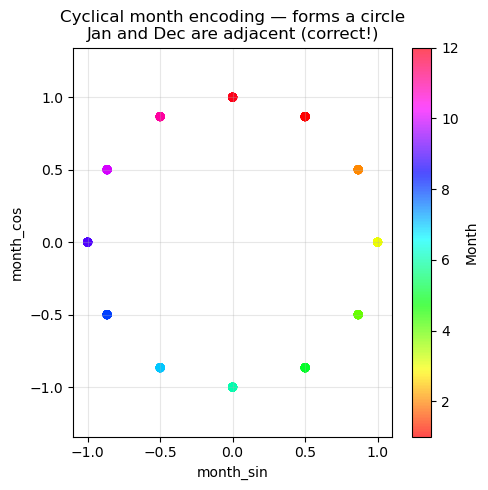

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Date/time feature extraction
dates = pd.date_range('2024-01-01', periods=365, freq='D')
df = pd.DataFrame({'date': dates, 'sales': np.sin(np.arange(365)*2*np.pi/365)*100 + 200})

df['year']       = df['date'].dt.year
df['month']      = df['date'].dt.month
df['day_of_week']= df['date'].dt.dayofweek
df['day_of_year']= df['date'].dt.dayofyear
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Cyclical encoding for month (1-12) and day of week (0-6)
df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin']     = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']     = np.cos(2 * np.pi * df['day_of_week'] / 7)

print('Features after date decomposition:')
print(df[['date','month','month_sin','month_cos','is_weekend']].head(7))

# Visualise cyclical encoding — months form a circle
plt.figure(figsize=(5, 5))
sc = plt.scatter(df['month_sin'], df['month_cos'],
                  c=df['month'], cmap='hsv', s=30, alpha=0.7)
plt.colorbar(sc, label='Month')
plt.xlabel('month_sin')
plt.ylabel('month_cos')
plt.title('Cyclical month encoding — forms a circle\nJan and Dec are adjacent (correct!)')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
# 10. Linear Algebra for ML

---
## Polynomial Features

Regular linear models can only draw straight lines (or hyperplanes).
**Polynomial features** extend them to curves by adding squared and
cross-product terms as new columns.

For two features x₁ and x₂, `degree=2` generates:
`[1, x₁, x₂, x₁², x₁x₂, x₂²]`

- `x₁²` — allows a U-shaped (quadratic) response
- `x₁x₂` — interaction: effect of x₁ depends on value of x₂

**When to use:**
- When you suspect a curved relationship (confirmed by residual plot)
- With linear models (Ridge, Lasso) — tree models learn these automatically
- Degree ≥ 3 usually overfits; stick to `degree=2`

**Warning:** With 20 features and degree=2, you get 231 columns.
Always combine with regularisation (Ridge/Lasso) when using polynomial features.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import warnings; warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Synthetic curved data ────────────────────────────────────────────────────
x     = np.linspace(-3, 3, 200).reshape(-1, 1)
y     = 0.5*x.ravel()**2 - x.ravel() + np.random.normal(0, 0.4, 200)
X_tr, X_te, y_tr, y_te = train_test_split(x, y, test_size=0.3, random_state=42)

xs_plot = np.linspace(-3, 3, 300).reshape(-1,1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, degree, color in zip(axes, [1, 2, 3], ['coral','seagreen','steelblue']):
    pipe = Pipeline([
        ('poly',  PolynomialFeatures(degree=degree, include_bias=False)),
        ('scale', StandardScaler()),
        ('model', Ridge(alpha=1.0)),
    ])
    pipe.fit(X_tr, y_tr)
    preds_line = pipe.predict(xs_plot)
    r2 = r2_score(y_te, pipe.predict(X_te))

    n_feats = PolynomialFeatures(degree).fit_transform(X_tr).shape[1]
    ax.scatter(X_tr, y_tr, alpha=0.4, s=15, color='lightgray', label='train')
    ax.scatter(X_te, y_te, alpha=0.6, s=15, color='black',     label='test')
    ax.plot(xs_plot, preds_line, color=color, lw=2.5,
            label=f'degree={degree}  R²={r2:.3f}')
    ax.set_title(f'PolynomialFeatures(degree={degree})\n{n_feats} features  R²={r2:.3f}', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Polynomial Features — Linear model learning curves', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

# Show what degree=2 actually creates
pf = PolynomialFeatures(degree=2, include_bias=False)
import pandas as pd
X_demo = pd.DataFrame({'x1':[2.0],'x2':[3.0]})
X_poly = pd.DataFrame(pf.fit_transform(X_demo), columns=pf.get_feature_names_out())
print('Input:              x1=2, x2=3')
print('degree=2 outputs:')
print(X_poly.T.rename(columns={0:'value'}).to_string())


---
## The 7 Feature Engineering Transformations — Detailed

These are the transformations applied in the House Price notebook.
Each has a specific motivation grounded in domain knowledge.


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import kagglehub, os, warnings
warnings.filterwarnings('ignore')

path  = kagglehub.competition_download('house-prices-advanced-regression-techniques')
train = pd.read_csv(os.path.join(path, 'train.csv'))
log_p = np.log1p(train['SalePrice'])
print(f'Loaded {train.shape[0]} rows')


In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flat

# ── 1. AGGREGATION: TotalSF ───────────────────────────────────────────────────
train['TotalSF'] = train['TotalBsmtSF'].fillna(0) + train['1stFlrSF'].fillna(0) + train['2ndFlrSF'].fillna(0)

ax = next(axes)
ax.scatter(train['TotalBsmtSF'], log_p, alpha=0.2, s=8, color='lightgray', label='TotalBsmtSF')
ax.set_title('Transformation 1\nBEFORE: partial areas separate', fontsize=9)
ax.set_xlabel('TotalBsmtSF'); ax.legend(fontsize=7)

ax = next(axes)
ax.scatter(train['TotalSF'], log_p, alpha=0.2, s=8, color='seagreen')
r = train['TotalSF'].corr(log_p)
ax.set_title(f'Transformation 1 — AGGREGATION\nTotalSF = bsmt+1st+2nd  r={r:.3f}', fontsize=9)
ax.set_xlabel('TotalSF')

# ── 2. DERIVED RATIO: HouseAge ────────────────────────────────────────────────
train['HouseAge'] = train['YrSold'] - train['YearBuilt']

ax = next(axes)
ax.scatter(train['YearBuilt'], log_p, alpha=0.2, s=8, color='lightgray')
r0 = train['YearBuilt'].corr(log_p)
ax.set_title(f'Transformation 2\nBEFORE: YearBuilt  r={r0:.3f}', fontsize=9)
ax.set_xlabel('YearBuilt')

ax = next(axes)
ax.scatter(train['HouseAge'], log_p, alpha=0.2, s=8, color='steelblue')
r = train['HouseAge'].corr(log_p)
ax.set_title(f'Transformation 2 — DERIVED RATIO\nHouseAge=YrSold-YearBuilt  r={r:.3f}', fontsize=9)
ax.set_xlabel('HouseAge (years at sale)')

# ── 3. DERIVED RATIO: RemodAge ────────────────────────────────────────────────
train['RemodAge'] = train['YrSold'] - train['YearRemodAdd']

ax = next(axes)
ax.scatter(train['YearRemodAdd'], log_p, alpha=0.2, s=8, color='lightgray')
ax.set_title('Transformation 3\nBEFORE: YearRemodAdd (absolute year)', fontsize=9)
ax.set_xlabel('YearRemodAdd')

ax = next(axes)
ax.scatter(train['RemodAge'], log_p, alpha=0.2, s=8, color='coral')
r = train['RemodAge'].corr(log_p)
ax.set_title(f'Transformation 3 — DERIVED RATIO\nRemodAge=YrSold-YearRemodAdd  r={r:.3f}', fontsize=9)
ax.set_xlabel('Remodel age (years since reno)')

# ── 4. WEIGHTED SUM: TotalBath ────────────────────────────────────────────────
train['TotalBath'] = train['FullBath'].fillna(0) + 0.5 * train['HalfBath'].fillna(0)

ax = next(axes)
ax.scatter(train['FullBath'], log_p, alpha=0.3, s=8, color='lightgray')
ax.set_title('Transformation 4\nBEFORE: FullBath (ignores half-baths)', fontsize=9)
ax.set_xlabel('FullBath')

ax = next(axes)
ax.scatter(train['TotalBath'], log_p, alpha=0.3, s=8, color='mediumpurple')
r = train['TotalBath'].corr(log_p)
ax.set_title(f'Transformation 4 — WEIGHTED SUM\nTotalBath=Full+0.5×Half  r={r:.3f}', fontsize=9)
ax.set_xlabel('TotalBath (weighted)')

# ── 5. LOG TRANSFORM: LogLotArea ─────────────────────────────────────────────
train['LogLotArea'] = np.log1p(train['LotArea'])

ax = next(axes)
ax.scatter(train['LotArea'], log_p, alpha=0.2, s=8, color='lightgray')
r0 = train['LotArea'].corr(log_p)
ax.set_title(f'Transformation 5\nBEFORE: LotArea  r={r0:.3f}\n(outliers dominate)', fontsize=9)
ax.set_xlabel('LotArea (raw)')

ax = next(axes)
ax.scatter(train['LogLotArea'], log_p, alpha=0.2, s=8, color='darkorange')
r = train['LogLotArea'].corr(log_p)
ax.set_title(f'Transformation 5 — LOG TRANSFORM\nlog(LotArea)  r={r:.3f}', fontsize=9)
ax.set_xlabel('log(LotArea)')

# ── 6. INTERACTION TERM: QualArea ────────────────────────────────────────────
train['QualArea'] = train['OverallQual'] * train['GrLivArea']

ax = next(axes)
ax.scatter(train['OverallQual'], log_p, alpha=0.3, s=8, color='lightgray')
r0 = train['OverallQual'].corr(log_p)
ax.set_title(f'Transformation 6\nBEFORE: OverallQual alone  r={r0:.3f}', fontsize=9)
ax.set_xlabel('OverallQual')

ax = next(axes)
sc = ax.scatter(train['QualArea'], log_p, alpha=0.2, s=8,
                c=train['OverallQual'], cmap='RdYlGn')
r = train['QualArea'].corr(log_p)
ax.set_title(f'Transformation 6 — INTERACTION\nQualArea=Qual×Area  r={r:.3f}\n'
             '(colour = quality grade)', fontsize=9)
ax.set_xlabel('QualArea')

# ── 7. BINARY FLAG: IsNew ────────────────────────────────────────────────────
train['IsNew'] = (train['YearBuilt'] >= 2000).astype(int)

ax = next(axes)
ax.hist(train.loc[train['IsNew']==0,'SalePrice']/1000, bins=40,
        alpha=0.6, color='steelblue', label='Old (pre-2000)')
ax.hist(train.loc[train['IsNew']==1,'SalePrice']/1000, bins=40,
        alpha=0.6, color='seagreen', label='New (2000+)')
ax.set_xlabel('SalePrice ($k)')
ax.set_title('Transformation 7 — BINARY FLAG\nIsNew = YearBuilt>=2000\nNew builds command a premium', fontsize=9)
ax.legend(fontsize=7)

# hide unused axes
for ax in axes:
    ax.axis('off')

plt.suptitle('7 Feature Engineering Transformations — Before and After', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

# Summary table
print('=== CORRELATION IMPROVEMENT SUMMARY ===')
pairs = [
    ('TotalBsmtSF', 'TotalSF',    'Aggregation'),
    ('YearBuilt',   'HouseAge',   'Derived ratio'),
    ('YearRemodAdd','RemodAge',   'Derived ratio'),
    ('FullBath',    'TotalBath',  'Weighted sum'),
    ('LotArea',     'LogLotArea', 'Log transform'),
    ('OverallQual', 'QualArea',   'Interaction term'),
]
print(f'  {"Before":15s}  r    {"After":15s}  r    Technique')
print(f'  {"-"*65}')
for before, after, tech in pairs:
    rb = train[before].corr(log_p)
    ra = train[after].corr(log_p)
    print(f'  {before:15s} {rb:+.3f}  {after:15s} {ra:+.3f}  {tech}')


---
## Outlier Detection — 4 Methods

Outliers are data points unusually far from the rest. They can skew
model parameters and inflate loss.

**Key rule:** Remove an outlier only when you have a *domain reason*.
A flagged point might be a legitimate extreme house — do not blindly delete
everything the algorithm marks.


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

# Use the house price data already loaded above
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Method 1: Visual ─────────────────────────────────────────────────────────
visual_outliers = (train['GrLivArea'] > 4000) & (train['SalePrice'] < 300_000)
axes[0,0].scatter(train['GrLivArea'], train['SalePrice']/1000,
                  alpha=0.3, s=10, color='steelblue')
axes[0,0].scatter(train.loc[visual_outliers,'GrLivArea'],
                  train.loc[visual_outliers,'SalePrice']/1000,
                  color='red', s=60, zorder=5, label='Flagged')
axes[0,0].set_title('Method 1: Visual Inspection\nLarge house, suspiciously low price', fontsize=10)
axes[0,0].set_xlabel('GrLivArea'); axes[0,0].set_ylabel('SalePrice ($k)')
axes[0,0].legend()

# ── Method 2: Z-score ────────────────────────────────────────────────────────
col = 'GrLivArea'
z = np.abs(stats.zscore(train[col].dropna()))
q1, q3 = train[col].quantile(0.25), train[col].quantile(0.75)
iqr_val = q3 - q1
axes[0,1].hist(train[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,1].axvline(train[col].mean() + 3*train[col].std(), color='red', lw=2,
                  label=f'mean+3std (Z-score)')
axes[0,1].axvline(q3 + 3*iqr_val, color='orange', lw=2, linestyle='--',
                  label=f'Q3+3×IQR')
axes[0,1].set_title('Methods 2 & 3: Z-score vs IQR fences\non GrLivArea', fontsize=10)
axes[0,1].set_xlabel(col); axes[0,1].legend(fontsize=8)

# ── Method 3: IQR (box plot) ─────────────────────────────────────────────────
axes[1,0].boxplot(train[col].dropna(), vert=False, whis=3.0,
                  medianprops=dict(color='red',lw=2))
axes[1,0].set_title('Method 3: Box Plot (IQR)\nDots beyond whiskers = outliers', fontsize=10)
axes[1,0].set_xlabel(col)

# ── Method 4: Isolation Forest ───────────────────────────────────────────────
feats = train[['GrLivArea','TotalBsmtSF','OverallQual','SalePrice']].dropna()
iso   = IsolationForest(contamination=0.02, random_state=42)
labels= iso.fit_predict(feats)
scores= iso.score_samples(feats)
sc = axes[1,1].scatter(feats['GrLivArea'], feats['SalePrice']/1000,
                       c=scores, cmap='RdYlGn', alpha=0.5, s=12)
plt.colorbar(sc, ax=axes[1,1], label='Anomaly score (red=outlier)')
axes[1,1].set_title('Method 4: Isolation Forest\nGreen=normal, Red=anomalous', fontsize=10)
axes[1,1].set_xlabel('GrLivArea'); axes[1,1].set_ylabel('SalePrice ($k)')

plt.suptitle('Outlier Detection — 4 Methods', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

n_z   = (np.abs(stats.zscore(train['GrLivArea'].fillna(train['GrLivArea'].median()))) > 3).sum()
n_iqr = ((train['GrLivArea'] < q1-3*iqr_val) | (train['GrLivArea'] > q3+3*iqr_val)).sum()
n_if  = (labels == -1).sum()
print(f'Z-score flagged    : {n_z}  rows  (|z|>3)')
print(f'IQR flagged        : {n_iqr}  rows  (3× IQR fence)')
print(f'Isolation Forest   : {n_if} rows  (2% contamination)')
print(f'Visual             : {visual_outliers.sum()}  rows  (domain knowledge)')
print()
print('Decision: Remove only the 2 visual outliers (SaleCondition=Partial = partial sale)')
print('All other flagged rows are genuine extreme-but-valid houses.')


---
## Mean / Target Encoding

Standard ordinal encoding assigns **arbitrary integers** to categories.
`Neighborhood = 'NoRidge'` → 14, `'OldTown'` → 22.
These numbers carry no price information.

**Target encoding** replaces each category with the **mean of the target**
in that category:
- `'NoRidge'` → mean log(SalePrice) of all NoRidge houses ≈ 12.3
- `'OldTown'` → mean log(SalePrice) ≈ 11.6

This embeds real price signal directly into the feature.

**Leakage risk:** If you use the training labels to encode training rows,
the model can see its own answers. `sklearn.preprocessing.TargetEncoder`
handles this with internal cross-fitting (k-fold within training data).


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import TargetEncoder, OrdinalEncoder
import warnings; warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Compare ordinal vs target encoding for Neighborhood ──────────────────────
nbr = train[['Neighborhood']].copy()
log_price = np.log1p(train['SalePrice'])

ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
tgt_enc = TargetEncoder(cv=5, random_state=42)

nbr_ord = ord_enc.fit_transform(nbr).ravel()
nbr_tgt = tgt_enc.fit_transform(nbr, log_price).ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(nbr_ord, log_price, alpha=0.2, s=8, color='steelblue')
axes[0].set_xlabel('Ordinal encoded Neighborhood (arbitrary integer)')
axes[0].set_ylabel('log(SalePrice)')
axes[0].set_title('Ordinal encoding: no signal\n(integer is meaningless)', fontsize=10)

axes[1].scatter(nbr_tgt, log_price, alpha=0.2, s=8, color='seagreen')
axes[1].set_xlabel('Target-encoded Neighborhood (mean log-price of that neighborhood)')
axes[1].set_ylabel('log(SalePrice)')
r = np.corrcoef(nbr_tgt, log_price)[0,1]
axes[1].set_title(f'Target encoding: strong signal r={r:.3f}\n'
                  '(encodes actual price level of each neighborhood)', fontsize=10)

plt.suptitle('Target Encoding vs Ordinal Encoding for Neighborhood',
             fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

nbr_means = pd.DataFrame({'neighborhood': train['Neighborhood'],
                           'log_price': log_price,
                           'target_encoded': nbr_tgt})
top5 = nbr_means.groupby('neighborhood').agg(
    median_price=('log_price','median'),
    target_enc=('target_encoded','mean'),
).sort_values('median_price', ascending=False).head(5)
print('Top 5 neighborhoods by price — target encoded value ≈ median log-price:')
print(top5.round(3).to_string())
